# 🚀 Fase 5: O Toque de Mestre (Time Embeddings & HPO)

Nesta etapa final, vamos lapidar nossos modelos com duas técnicas avançadas de MLOps:
1. **Time Embeddings (Seno/Cosseno):** Substituir a representação linear de tempo (Mês 1-12) por coordenadas trigonométricas cíclicas.
2. **Otimização Bayesiana (Optuna):** Abandonar o modelo *default* e buscar a Árvore perfeita para as complexidades das Wavelets e Decomposições.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
import pywt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('dark_background')



## 1. Carregamento e Time Embeddings


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"
df_raw = pd.read_csv(url)

df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])
cols_of_interest = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
df_raw = df_raw[['date'] + cols_of_interest].copy()
df_raw['pm2.5'] = df_raw['pm2.5'].interpolate(method='linear')
df_raw = df_raw.dropna()

df_daily = df_raw.set_index('date').resample('D').mean().reset_index()
df_daily['target'] = df_daily['pm2.5'].shift(-1)

# Base Temporal (As outras features serão coladas nisto)
df_base = df_daily[['date']].copy()

# TIME EMBEDDINGS (Mês e Dia da Semana Circulares)
month = df_base['date'].dt.month
dow = df_base['date'].dt.dayofweek

df_base['month_sin'] = np.sin(2 * np.pi * month / 12)
df_base['month_cos'] = np.cos(2 * np.pi * month / 12)
df_base['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df_base['dow_cos'] = np.cos(2 * np.pi * dow / 7)



## 2. Extração Acelerada das Features Anteriores


In [3]:
print("Calculando Lags, Sazonalidade e Wavelets...")

# MANUAL FE
df_manual = pd.DataFrame(index=df_daily.index)
lags = [1, 2, 3, 7]
for col in cols_of_interest:
    for lag in lags:
        df_manual[f'{col}_lag_{lag}'] = df_daily[col].shift(lag)
    df_manual[f'{col}_rolling_mean_7'] = df_daily[col].rolling(window=7).mean()

# SAZONAL DECOMPOSITION
df_decomp = pd.DataFrame(index=df_daily.index)
safe_shift = (7 // 2) + 1 
for col in cols_of_interest:
    decomp = seasonal_decompose(df_daily[col].fillna(method='bfill'), model='additive', period=7, extrapolate_trend='freq')
    df_decomp[f'{col}_trend'] = decomp.trend.shift(safe_shift)
    df_decomp[f'{col}_seasonal'] = decomp.seasonal.shift(safe_shift)
    df_decomp[f'{col}_resid'] = decomp.resid.shift(safe_shift)

# WAVELETS (DWT)
window_size = 7
wavelet_name = 'db2' 
wavelet_features = []
for i in range(len(df_daily)):
    if i < window_size - 1:
        row_features = {f'{col}_dwt_cA_mean': np.nan for col in cols_of_interest}
    else:
        row_features = {}
        for col in cols_of_interest:
            window = df_daily[col].iloc[i - window_size + 1 : i + 1].values
            cA, cD = pywt.dwt(window, wavelet_name)
            row_features[f'{col}_dwt_cA_mean'] = np.mean(cA)
            row_features[f'{col}_dwt_cA_std'] = np.std(cA)
            row_features[f'{col}_dwt_cD_mean'] = np.mean(cD)
            row_features[f'{col}_dwt_cD_std'] = np.std(cD)
    wavelet_features.append(row_features)
df_wavelet = pd.DataFrame(wavelet_features, index=df_daily.index)

print("Extrações Concluídas!")



Calculando Lags, Sazonalidade e Wavelets...


Extrações Concluídas!


## 3. Montagem dos Cenários e Otimização Bayesiana (Optuna)



--- Otimizando: 1. Apenas Manual FE (+Time Emb & HPO) ---


Melhores parâmetros: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 5}


[1. Apenas Manual FE (+Time Emb & HPO)] MAE (Teste Final): 57.1488 | Tempo Treino: 0.48s

--- Otimizando: 2. Apenas Decomp Sazonal (+Time Emb & HPO) ---


Melhores parâmetros: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 4}


[2. Apenas Decomp Sazonal (+Time Emb & HPO)] MAE (Teste Final): 59.6319 | Tempo Treino: 0.34s

--- Otimizando: 3. Apenas Wavelets (+Time Emb & HPO) ---


Melhores parâmetros: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5}
[3. Apenas Wavelets (+Time Emb & HPO)] MAE (Teste Final): 56.7428 | Tempo Treino: 0.12s

--- Otimizando: 4. Híbrido Total (+Time Emb & HPO) ---


Melhores parâmetros: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 2}


[4. Híbrido Total (+Time Emb & HPO)] MAE (Teste Final): 55.2589 | Tempo Treino: 0.77s


,Cenário,N_Features,MAE,RMSE,Train_Time(s)
3,4. Híbrido Total (+Time Emb & HPO),64,55.258906,75.277569,0.767683
2,3. Apenas Wavelets (+Time Emb & HPO),24,56.742813,76.809183,0.121675
0,1. Apenas Manual FE (+Time Emb & HPO),29,57.148791,77.098293,0.481498
1,2. Apenas Decomp Sazonal (+Time Emb & HPO),19,59.631884,80.638806,0.337411


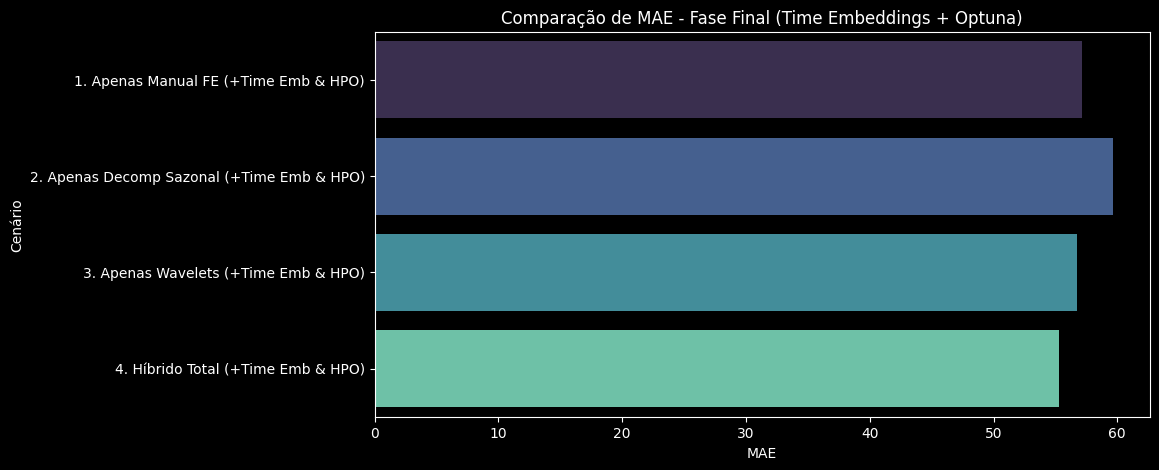

In [4]:
df_full = pd.concat([df_daily[['target']], df_base, df_manual, df_decomp, df_wavelet], axis=1).dropna()

y = df_full['target']
time_cols = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos']

# Criando as matrizes X (todas agora incluem os Time Embeddings!)
X_manual_t = df_full[time_cols + df_manual.columns.tolist()]
X_decomp_t = df_full[time_cols + df_decomp.columns.tolist()]
X_wavelet_t = df_full[time_cols + df_wavelet.columns.tolist()]
X_hybrid_t = df_full.drop(columns=['target', 'date'])

test_size = 365
results = []

def optimize_and_train(X, name):
    print(f"\n--- Otimizando: {name} ---")
    X_train_full = X.iloc[:-test_size]
    y_train_full = y.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_test = y.iloc[-test_size:]
    
    # Validação Cruzada Temporal para o Optuna
    tscv = TimeSeriesSplit(n_splits=3)
    
    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
        max_depth = trial.suggest_categorical('max_depth', [5, 10, 20, None])
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        
        cv_scores = []
        for train_idx, val_idx in tscv.split(X_train_full):
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                n_jobs=-1
            )
            rf.fit(X_train_full.iloc[train_idx], y_train_full.iloc[train_idx])
            preds = rf.predict(X_train_full.iloc[val_idx])
            cv_scores.append(mean_absolute_error(y_train_full.iloc[val_idx], preds))
            
        return np.mean(cv_scores)
    
    # 10 trials para otimização rápida
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=10)
    
    best_params = study.best_params
    print(f"Melhores parâmetros: {best_params}")
    
    # Treinar modelo final com os melhores parametros no dataset inteiro de treino
    best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    
    start = time.time()
    best_rf.fit(X_train_full, y_train_full)
    t_time = time.time() - start
    
    preds = best_rf.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Cenário': name,
        'N_Features': X_train_full.shape[1],
        'MAE': mae,
        'RMSE': rmse,
        'Train_Time(s)': t_time
    })
    print(f"[{name}] MAE (Teste Final): {mae:.4f} | Tempo Treino: {t_time:.2f}s")

optimize_and_train(X_manual_t, '1. Apenas Manual FE (+Time Emb & HPO)')
optimize_and_train(X_decomp_t, '2. Apenas Decomp Sazonal (+Time Emb & HPO)')
optimize_and_train(X_wavelet_t, '3. Apenas Wavelets (+Time Emb & HPO)')
optimize_and_train(X_hybrid_t, '4. Híbrido Total (+Time Emb & HPO)')

res_df = pd.DataFrame(results)
display(res_df.sort_values('MAE'))

plt.figure(figsize=(10,5))
sns.barplot(data=res_df, x='MAE', y='Cenário', palette='mako')
plt.title('Comparação de MAE - Fase Final (Time Embeddings + Optuna)')
plt.show()

